# Code for Genreating Data of Toggle Objective Separation

## Imports

In [1]:
import Pkg; Pkg.activate(@__DIR__); Pkg.instantiate();
Pkg.develop(path="../../QuantumCollocation.jl")
using Revise
# using Piccolo
using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using LaTeXStrings
using SparseArrays
using Statistics
using CairoMakie
using Random
using NamedTrajectories
using JLD2, FileIO

  Activating project at `~/Documents/research/pulses/project/notebooks/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
   Resolving package versions...
  No Changes to `~/Documents/research/pulses/project/notebooks/src/Project.toml`
  No Changes to `~/Documents/research/pulses/project/notebooks/src/Manifest.toml`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
┌ Warning: Replacing docs for `QuantumCollocation.ProblemTemplates.UnitaryUniversalProblem :: Union{}` in module `QuantumCollocation.ProblemTemplates`
└ @ Base.Docs docs/Docs.jl:243
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Warning: Replacing docs

In [15]:
# Problem parameters
T = 20
Δt = 1.6
U_goal = GATES.H
H_drive = [PAULIS.X, PAULIS.Y, PAULIS.Z]
piccolo_opts = PiccoloOptions(verbose=false)
pretty_print(X::AbstractMatrix) = Base.show(stdout, "text/plain", X);
sys = QuantumSystem(H_drive)
seeds = rand(1:1000, 2)
F=0.9999
num_iter = 6000
hess = false
hes_iter = 150
Q = 10.0
a_bound = 1.0
dda_bound = 0.5
R=5e-3

0.005

Optimize Toggle Objective

In [ ]:
# Adjoint, rollout initialization

∂ₑHₐ = [PAULIS.Z]
pert_sys = VariationalQuantumSystem(
    H_drive,
    ∂ₑHₐ
)

n_seeds = length(seeds)
tog_probs = []

var_count = length(pert_sys.G_vars)

for seed in seeds   
    Random.seed!(seed)
    tog_prob = UnitaryToggleProblem(
        pert_sys, U_goal, T, Δt;
        a_bound=a_bound, 
        dda_bound=dda_bound,
        Δt_max=Δt,
        Δt_min=Δt,
        fast=false,
        Q=0.0,
        Q_t = Q,
        R=R,
        piccolo_options = PiccoloOptions(verbose=false)
    )
    push!(
        tog_prob.constraints, 
        FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, tog_prob.trajectory)
    );
    solve!(tog_prob, max_iter=num_iter, print_level=0, options=IpoptOptions(eval_hessian=false))
    solve!(tog_prob, max_iter=hes_iter, print_level=0, options=IpoptOptions(eval_hessian=true))
    push!(tog_probs, tog_prob)
end

    initializing optimizer...
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
    initializing optimizer...
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
    initializing optimizer...
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying co

Optimize Variational Objective

In [17]:
# Adjoint, rollout initialization

∂ₑHₐ = [PAULIS.Z]
varsys_add = VariationalQuantumSystem(
    H_drive,
    ∂ₑHₐ
)
n_seeds = length(seeds)
var_probs = []

var_count = length(varsys_add.G_vars)

for seed in seeds
    Random.seed!(seed)
    var_count = length(varsys_add.G_vars)

    var_prob = UnitaryVariationalProblem(
        varsys_add, U_goal, T, Δt;
        robust_times = [[T] for _ in 1:var_count],
        a_bound=a_bound, 
        dda_bound=dda_bound,
        Δt_max=Δt,
        Δt_min=Δt,
        Q=0.0,
        Q_r = 1.0,   # > 0
        Q_s = 0.0,     # (irrelevant since sensitive_times is empty)
        piccolo_options = PiccoloOptions(verbose=false)
    )

    # Initialize with a rollout, not the geodesic
    init_traj = deepcopy(var_prob.trajectory)
    init_traj.Ũ⃗ .= unitary_rollout(init_traj, varsys_add)

    var_prob = UnitaryVariationalProblem(
            varsys_add, U_goal, T, Δt;
            robust_times = [[T] for _ in 1:var_count],
            a_bound=a_bound, 
            dda_bound=dda_bound,
            Δt_max=Δt,
            Δt_min=Δt,
            Q=0.0,
            Q_r = Q,
            Q_s = 0.0,
            R=R,
            piccolo_options = PiccoloOptions(verbose=false)
        )
    push!(
        var_prob.constraints, 
        FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, var_prob.trajectory)
    );
    solve!(var_prob, max_iter=num_iter, print_level=0, options=IpoptOptions(eval_hessian=false))
    solve!(var_prob, max_iter=hes_iter, print_level=0, options=IpoptOptions(eval_hessian=true))
    push!(var_probs, var_prob)
end

    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: initial value of Ũ⃗ᵥ1
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: initial value of Ũ⃗ᵥ1
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
    initializing optimizer...
        applying constraint: timesteps all equal constraint
      

Optimize Upsamnpled Toggle Objective

In [18]:
# Problem parameters
up_factor = 4
T_up = 20*up_factor
Δt_up = 1.6/up_factor
ups_probs = []

var_count = length(pert_sys.G_vars)

for seed in seeds
    Random.seed!(seed)
    ups_prob = UnitaryToggleProblem(
        pert_sys, U_goal, T_up, Δt_up;
        a_bound=a_bound, 
        dda_bound=dda_bound,
        Δt_max=Δt,
        Δt_min=Δt,
        fast=false,
        Q=0.0,
        Q_t = Q,
        R=R,
        piccolo_options = PiccoloOptions(verbose=false)
    )
    push!(
        ups_prob.constraints, 
        FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, ups_prob.trajectory)
    );
    solve!(ups_prob, max_iter=num_iter, print_level=0, options=IpoptOptions(eval_hessian=false))
    solve!(ups_prob, max_iter=hes_iter, print_level=0, options=IpoptOptions(eval_hessian=true))
    push!(ups_probs, ups_prob)
end

    initializing optimizer...
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
    initializing optimizer...
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
    initializing optimizer...
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying co

### Objectives for evalulation

In [19]:
∂ₑH = [PAULIS.Z]
H_drives = [PAULIS.X, PAULIS.Y, PAULIS.Z]
error_ops = [PAULIS.Z]

function var_obj(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}}, 
    H_errors::Vector{Matrix{ComplexF64}}
)
    Δt = traj.Δt[1]
    pert_sys = VariationalQuantumSystem(H_drives, H_errors)
    Ũ⃗, ∂Ũ⃗ = variational_unitary_rollout(traj, pert_sys)

    U = iso_vec_to_operator(Ũ⃗[:, end])
    # First error term
    ∂U = iso_vec_to_operator(∂Ũ⃗[1][:, end])

    d = size(U, 1)
    return abs(tr((U'*∂U)'*(U'*∂U))) / (T * Δt)^2 / d
end

# J_var = tog_obj(tog_prob.trajectory, H_drives, error_ops)

var_obj (generic function with 1 method)

In [20]:
function tog_obj(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}},
    H_error::Matrix{ComplexF64}
)
    T = traj.T
    Δt = get_timesteps(traj)

    sys = QuantumSystem(H_drives)
    U = iso_vec_to_operator.(eachcol(unitary_rollout(traj, sys)))
    
    # Toggle integral
    H_ti = sum(Δt[i] .* U[i]' * H_error * U[i] for i=1:T-1)

    d₁ = size(U[1], 1)
    Δt₁ = Δt[1]
    metric = norm(tr(H_ti'H_ti)) / (T * Δt₁)^2 / d₁
    return metric
end


tog_obj (generic function with 1 method)

In [21]:
"""
    upsample_constant(vals, dts; factor=2)

Take control values `vals` with time steps `dts` (same length),
and upsample by `factor`, returning (vals_up, dts_up).
"""
function upsample_constant_controls(vals::AbstractArray; factor::Int=2)
    vals_up = repeat(vals, inner=factor)
    return vals_up
end

# Example
vals = [1, 2, 3]
dts  = [0.2, 0.2, 0.2]

vals_up = upsample_constant_controls(vals; factor=3)

println(vals_up)  # [1, 1, 2, 2, 3, 3]
#println(dts_up) 
function upsample_matrix(controls::AbstractArray, dts::AbstractArray; factor::Int=2)
    new_controls = []
    for c in eachrow(controls)
        new_c = upsample_constant_controls(c; factor=factor)
        T = length(c)
        push!(new_controls, new_c)
    end
    dts_up = dts[1] / factor .* ones(length(dts) * factor*T)
    new_controls = reduce(vcat, [v' for v in new_controls])
    return new_controls, dts_up
end
function tog_obj_upsample(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}},
    H_error::Matrix{ComplexF64};
    factor::Int=1
)
    T = traj.T * factor
    controls = traj.a
    a_new, Δt_new = upsample_matrix(traj.a, traj.Δt; factor=factor)

    sys = QuantumSystem(H_drives)
    U = iso_vec_to_operator.(eachcol(unitary_rollout(a_new, Δt_new, sys)))
    
    # Toggle integral (truncate at (traj.T - 1) * factor)
    H_ti = sum(Δt_new[i] .* U[i]' * H_error * U[i] for i = 1:(traj.T - 1) * factor)

    d₁ = size(U[1], 1)
    Δt₁ = Δt_new[1]
    metric = norm(tr(H_ti'H_ti)) / (T * Δt₁)^2 / d₁
    return metric
end

[1, 1, 1, 2, 2, 2, 3, 3, 3]


tog_obj_upsample (generic function with 1 method)

In [22]:
function commutator(A::AbstractMatrix{<:Number}, B::AbstractMatrix{<:Number})
    return A*B - B*A
end
function pert_tog_obj(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}},
    H_error::Matrix{ComplexF64};
    order::Int=1,
    a_bound::Float64=a_bound
)
    T = traj.T
    Δt = get_timesteps(traj)

    sys = QuantumSystem(H_drives)
    U = iso_vec_to_operator.(eachcol(unitary_rollout(traj, sys)))

    # toggle integral
    H_ti = zeros(ComplexF64, size(U[1]))

    # note: U_1 = I, so U[:, k] = U_{k-1}.
    # you need to go to T-1, only
    for k in 1:T-1
        Hₖ = sum(traj.a[l, k] / a_bound * H for (l, H) in enumerate(H_drives))
        adjⁿH_E = H_error
        Eₖ_n = H_error * Δt[k]
        
        # get the different orders of the Hadamard lemma
        for n in 2:order
            coef_n = ComplexF64(im^(n-1) * a_bound^(n-1) * Δt[k]^n / factorial(big(n)))
            adjⁿH_E = commutator(Hₖ, adjⁿH_E)
            # Eₖ_n = push!(Eₖ_n, coef_n * adjⁿH_E)
            Eₖ_n += coef_n * adjⁿH_E
        end

        # nth order toggle integral up to k
        H_ti += U[k]' * Eₖ_n * U[k]
    end

    d₁ = size(U[1], 1)
    Δt₁ = Δt[1]
    metric = norm(tr(H_ti'H_ti)) / (T * Δt₁)^2 / d₁
    return metric
end

pert_tog_obj (generic function with 1 method)

### Plots

In [30]:
# identify optimal seeds

# Define H_drives and H_errors for objective calculations
H_drives = [PAULIS.X, PAULIS.Y, PAULIS.Z]
error_ops = [PAULIS.Z]  # Assuming single error operator

min_var_seed = nothing
min_var_obj_value = Inf

min_tog_seed = nothing
min_tog_obj_value = Inf

min_ups_seed = nothing
min_ups_obj_value = Inf

best_seed = nothing
max_diff = -Inf

for seed_idx in 1:n_seeds
    var_prob = var_probs[seed_idx]
    tog_prob = tog_probs[seed_idx]
    ups_prob = ups_probs[seed_idx]
    var_fidelity = unitary_rollout_fidelity(var_prob.trajectory, sys)
    tog_fidelity = unitary_rollout_fidelity(tog_prob.trajectory, sys)
    ups_fidelity = unitary_rollout_fidelity(ups_prob.trajectory, sys)

    if var_fidelity < 0.9999 || tog_fidelity < 0.9999 || ups_fidelity < 0.9999
        continue
    end

    if !isnothing(var_prob) && !isnothing(tog_prob)

        v_obj = var_obj(var_prob.trajectory, H_drives, error_ops)
        t_obj = var_obj(tog_prob.trajectory, H_drives, error_ops)
        u_obj = var_obj(ups_prob.trajectory, H_drives, error_ops)

        if v_obj < min_var_obj_value
            min_var_obj_value = v_obj
            min_var_seed = seed_idx
            println("  New best var_obj: seed=$seed_idx, var_obj=$v_obj")
        end

        if t_obj < min_tog_obj_value
            min_tog_obj_value = t_obj
            min_tog_seed = seed_idx
            println("  New best tog_obj: seed=$seed_idx, tog_obj=$t_obj")
        end

        if u_obj < min_ups_obj_value
            min_ups_obj_value = u_obj
            min_ups_seed = seed_idx
            println("  New best ups_obj: seed=$seed_idx, ups_obj=$u_obj")
        end
    end
end

println("\n" * "="^70)
println("OPTIMAL SEEDS FOUND:")
println("="^70)
println("Minimum var_obj:")
println("  Seed index: $min_var_seed")
println("  var_obj value: $min_var_obj_value")

println("\nMin tog_obj:")
println("  Seed index: $min_tog_seed")
println("  tog_obj value: $min_tog_obj_value")


println("\nMin ups_obj:")
println("  Seed index: $min_ups_seed")
println("  ups_obj value: $min_ups_obj_value")


  New best var_obj: seed=1, var_obj=1.0790602674560594e-8
  New best tog_obj: seed=1, tog_obj=0.0013133663031776825
  New best ups_obj: seed=1, ups_obj=0.0012569128923316292
  New best var_obj: seed=2, var_obj=1.0790588510954455e-8
  New best ups_obj: seed=2, ups_obj=0.0012477213635873389

OPTIMAL SEEDS FOUND:
Minimum var_obj:
  Seed index: 2
  var_obj value: 1.0790588510954455e-8

Min tog_obj:
  Seed index: 1
  tog_obj value: 0.0013133663031776825

Min ups_obj:
  Seed index: 2
  ups_obj value: 0.0012477213635873389


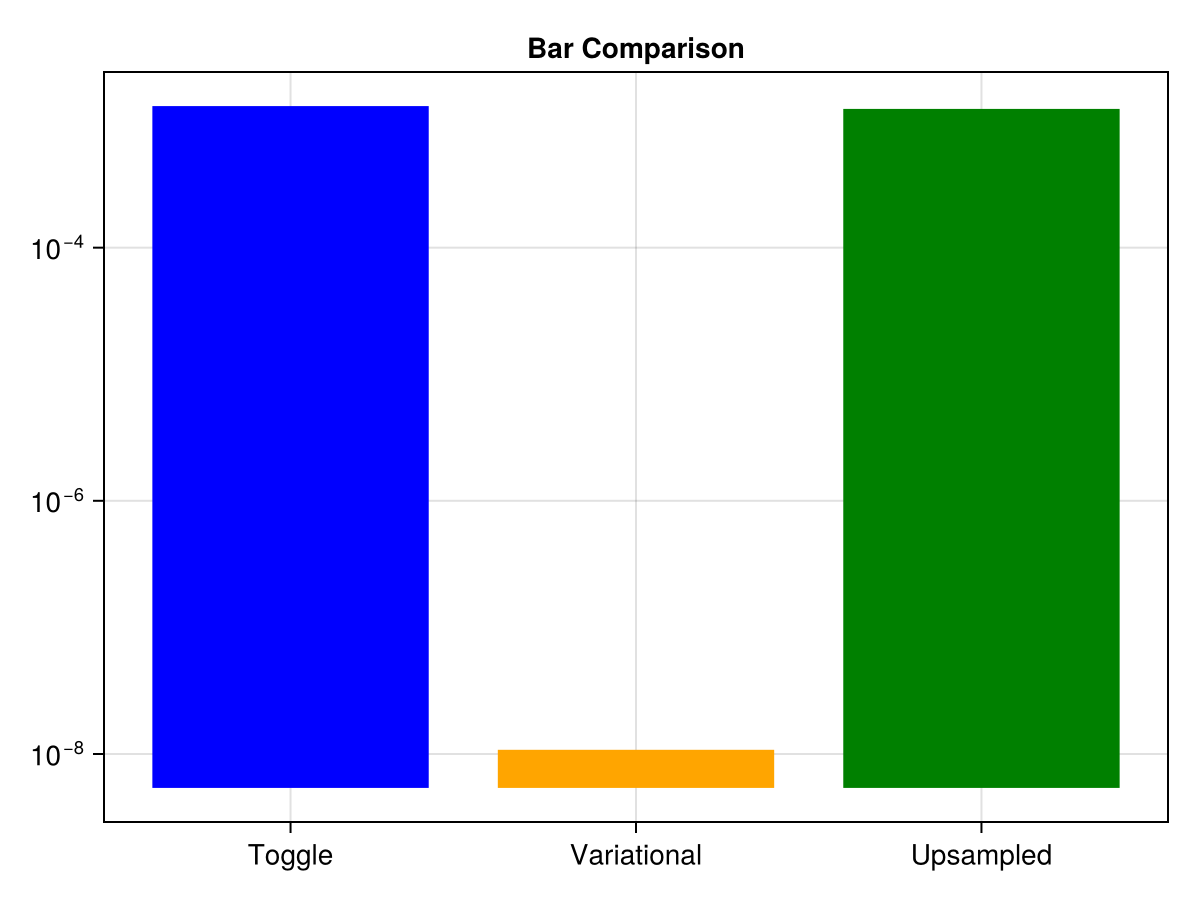

In [ ]:
# bar plot for optimal toggle vs. variational objective vs. upsampled comparison
# Use the best var seed for plotting
best_var = var_probs[min_var_seed]
best_tog = tog_probs[min_tog_seed]
best_ups = ups_probs[min_ups_seed]

best_var_traj = best_var.trajectory
best_tog_traj = best_tog.trajectory
best_ups_traj = best_ups.trajectory

best_var_val = var_obj(best_var_traj, H_drives, error_ops)
best_tog_val = var_obj(best_tog_traj, H_drives, error_ops)
best_ups_val = var_obj(best_ups_traj, H_drives, error_ops)

f = Figure()
ax = Axis(f[1, 1],
          xticks = (1:3, ["Toggle", "Variational", "Upsampled"]),
          title = "Bar Comparison",
          yscale=log10)

categories = 1:3
heights = [best_tog_val, best_var_val, best_ups_val]

barplot!(ax, categories, heights, color = [:blue, :orange, :green])

f

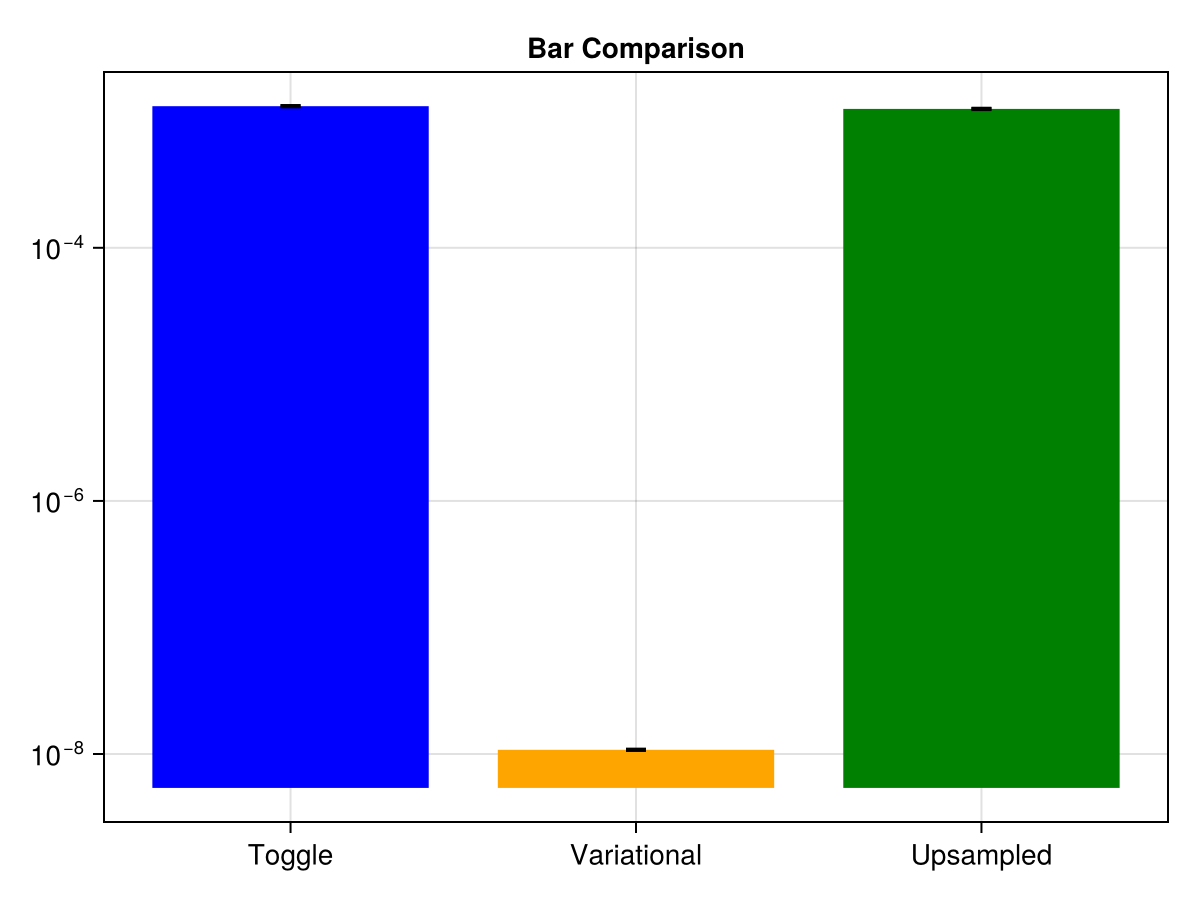

In [25]:
# Calculate objectives across seeds
tog_objs = [var_obj(tog_probs[i].trajectory, H_drives, error_ops) for i in 1:n_seeds]
var_objs = [var_obj(var_probs[i].trajectory, H_drives, error_ops) for i in 1:n_seeds]
ups_objs = [var_obj(ups_probs[i].trajectory, H_drives, error_ops) for i in 1:n_seeds]

# Calculate means
tog_mean = mean(tog_objs)
var_mean = mean(var_objs)
ups_mean = mean(ups_objs)

# Calculate standard errors (SEM)
tog_sem = std(tog_objs) / sqrt(n_seeds)
var_sem = std(var_objs) / sqrt(n_seeds)
ups_sem = std(ups_objs) / sqrt(n_seeds)

# Create plot
f = Figure()
ax = Axis(f[1, 1],
          xticks = (1:3, ["Toggle", "Variational", "Upsampled"]),
          title = "Bar Comparison",
          yscale=log10)

categories = 1:3
heights = [tog_mean, var_mean, ups_mean]
errors = [tog_sem, var_sem, ups_sem]

barplot!(ax, categories, heights, color = [:blue, :orange, :green])
errorbars!(ax, categories, heights, errors, color = :black, linewidth = 2, whiskerwidth = 10)

f

In [26]:
# Create the directory
artifacts_dir = "artifacts/main_fig_gap_data"
mkpath(artifacts_dir)

# Save the data and parameters
save(joinpath(artifacts_dir, "main_fig_gap_data.jld2"), Dict(
    "tog_probs" => tog_probs,
    "var_probs" => var_probs,
    "ups_probs" => ups_probs,
    "up_factor" => up_factor,
    "seeds" => seeds,
    "time_steps" = T,
    "Δt" = Δt,
    "Q" => Q,
    "F" => F,
    "num_iter" => num_iter,
    "hes_iter" => hes_iter,
    "a_bound" => a_bound,
    "dda_bound" => dda_bound,
    "R" => R
))

println("Data saved to $artifacts_dir")


ErrorException: syntax: invalid keyword argument name ""T"" around /Users/samafine1/Documents/research/pulses/project/notebooks/src/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X16sZmlsZQ==.jl:6